In [6]:
import math
def build_A_Q_for_p(p_true: float):
    """
    Build state-preparation A and Grover iterate Q for a single-qubit Bernoulli with success prob p_true.
    |0> --A--> sqrt(1-p)|0> + sqrt(p)|1>
    """
    theta_prep = 2 * math.asin(math.sqrt(p_true))   # rotation angle in RY
    theta_amp = theta_prep / 2                      # θ such that sin^2(θ) = p_true

    # A: single-qubit RY
    A = QuantumCircuit(1, name="A")
    A.ry(theta_prep, 0)

    # Grover iterate Q = A Z A† S1  (implemented as RY, Z, RY(-), XZX)
    Q = QuantumCircuit(1, name="Q")
    Q.ry(theta_prep, 0)
    Q.z(0)
    Q.ry(-theta_prep, 0)
    Q.x(0); Q.z(0); Q.x(0)

    return A, Q, theta_amp


def estimate_p_for_k(p_true: float, k: int, shots: int = 5000):
    """
    For a given p_true and Grover power k, run:
        A -> Q^k -> measure
    then invert amplitude to estimate p.
    """
    A, Q, theta_amp = build_A_Q_for_p(p_true)

    # Build full circuit A -> Q^k -> measure
    qc = QuantumCircuit(1, 1)
    qc.compose(A, inplace=True)
    for _ in range(k):
        qc.compose(Q, inplace=True)
    qc.measure(0, 0)

    # Sample
    result = sampler.run([qc], shots=shots).result()
    quasi = result.quasi_dists[0]
    p_k_est = quasi.get(1, 0.0)

    # If p_k_est is 0 or 1 numerically, arcsin can be unstable – handle edge cases
    eps = 1e-12
    p_k_clipped = min(max(p_k_est, eps), 1 - eps)

    # Invert amplification:
    # p_k ≈ sin^2((2k+1)*θ)  => θ has two branches
    alpha = math.asin(math.sqrt(p_k_clipped))

    theta1 = alpha / (2*k + 1)
    theta2 = (math.pi - alpha) / (2*k + 1)

    p1 = math.sin(theta1)**2
    p2 = math.sin(theta2)**2

    # Choose branch closer to the true p
    p_hat = p1 if abs(p1 - p_true) < abs(p2 - p_true) else p2

    return p_hat, p_k_est


In [7]:
# Amplitudes to test (you can adjust/extend this list)
p_values = [0.01, 0.05, 0.1, 0.15, 0.18, 0.2, 0.3, 0.4, 0.49]
ks = [0, 1, 2, 3]
shots = 5000

results = []  # list of dicts

for p_true in p_values:
    for k in ks:
        p_hat, p_k_est = estimate_p_for_k(p_true, k, shots=shots)
        err = abs(p_hat - p_true)
        results.append(
            {
                "p_true": p_true,
                "k": k,
                "M": 2*k + 1,           # oracle calls proxy
                "p_k_est": p_k_est,     # amplified probability measured
                "p_hat": p_hat,         # recovered original p
                "abs_error": err,
            }
        )

results


NameError: name 'QuantumCircuit' is not defined

In [8]:
from pprint import pprint

print("p_true   k   M   p_k_est      p_hat        abs_error")
for r in results:
    print(f"{r['p_true']:<6.2f}  {r['k']}   {r['M']}   "
          f"{r['p_k_est']:<10.4f}  {r['p_hat']:<10.4f}  {r['abs_error']:<10.4f}")


p_true   k   M   p_k_est      p_hat        abs_error


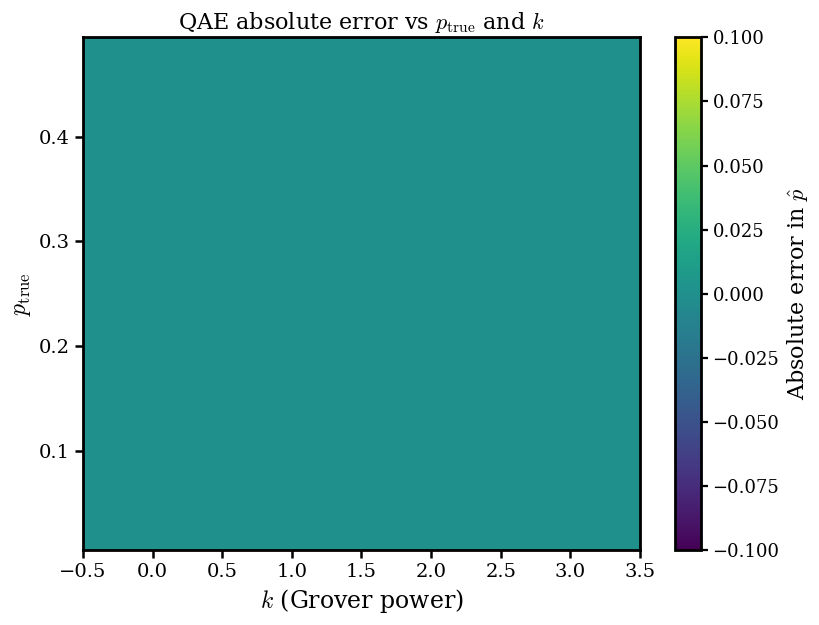

In [9]:
# Build a 2D array: rows = p_true, cols = k
p_indices = {p: i for i, p in enumerate(p_values)}
k_indices = {k: j for j, k in enumerate(ks)}
err_matrix = np.zeros((len(p_values), len(ks)))
for r in results:
    i = p_indices[r["p_true"]]
    j = k_indices[r["k"]]
    err_matrix[i, j] = r["abs_error"]

plt.rcParams.update({
    "font.size": 15,
    "axes.linewidth": 2.0,      # thicker graph border (spines)
})

fig, ax = plt.subplots(figsize=(8.5, 6.5))

im = ax.imshow(err_matrix, aspect="auto", origin="lower",
               extent=[min(ks)-0.5, max(ks)+0.5,
                       min(p_values)-0.005, max(p_values)+0.005])

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Absolute error in $\\hat{p}$", fontsize=16)
cbar.ax.tick_params(labelsize=13, width=1.6, length=5)
cbar.outline.set_linewidth(2.0)        # thicker colorbar border

ax.set_xlabel("$k$ (Grover power)", fontsize=17)
ax.set_ylabel("$p_{\\mathrm{true}}$", fontsize=17)
ax.set_title("QAE absolute error vs $p_{\\mathrm{true}}$ and $k$", fontsize=16)

ax.tick_params(axis='both', which='major', labelsize=14, width=1.8, length=6)

fig.tight_layout()
fig.savefig("stability_heatmap.pdf", bbox_inches='tight')   # use this in LaTeX
fig.savefig("stability_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

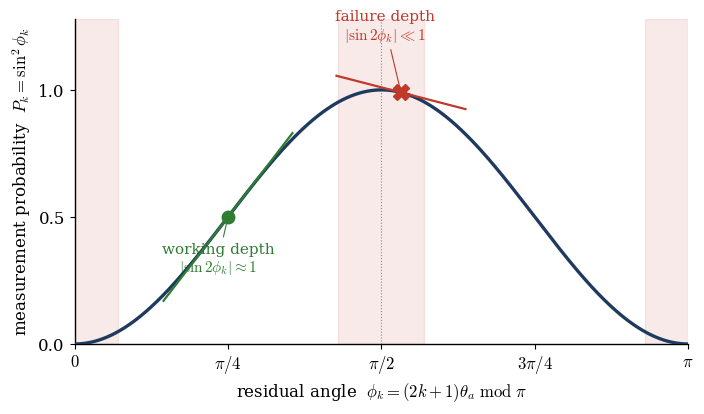

In [10]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.linewidth": 1.0,
    "mathtext.fontset": "cm",
})

NAVY, RED, GREEN, GREY = "#1f3a5f", "#c0392b", "#2e7d32", "#888888"

fig, ax = plt.subplots(figsize=(7.2, 4.3))

phi = np.linspace(0, np.pi, 600)
ax.plot(phi, np.sin(phi)**2, color=NAVY, lw=2.4, zorder=5)

# low-gradient (failure) zones near 0, pi/2, pi
band = 0.22
for c in [0.0, np.pi/2, np.pi]:
    ax.axvspan(max(0, c-band), min(np.pi, c+band), color=RED, alpha=0.10, zorder=0)

# working depth: high gradient near pi/4
phi_safe = np.pi/4
ax.plot([phi_safe], [np.sin(phi_safe)**2], 'o', color=GREEN, ms=9, zorder=6)
m = np.sin(2*phi_safe)
xs = np.linspace(phi_safe-0.33, phi_safe+0.33, 2)
ax.plot(xs, np.sin(phi_safe)**2 + m*(xs-phi_safe), color=GREEN, lw=1.6, zorder=6)
ax.annotate("working depth\n" + r"$|\sin 2\phi_k|\approx 1$",
            xy=(phi_safe, np.sin(phi_safe)**2), xytext=(phi_safe-0.05, 0.40),
            ha='center', va='top', color=GREEN, fontsize=11,
            arrowprops=dict(arrowstyle='-', color=GREEN, lw=0.8))

# failure depth: flat region near pi/2
phi_fail = np.pi/2 + 0.10
ax.plot([phi_fail], [np.sin(phi_fail)**2], 'X', color=RED, ms=11, zorder=6)
m = np.sin(2*phi_fail)
xf = np.linspace(phi_fail-0.33, phi_fail+0.33, 2)
ax.plot(xf, np.sin(phi_fail)**2 + m*(xf-phi_fail), color=RED, lw=1.6, zorder=6)
ax.annotate("failure depth\n" + r"$|\sin 2\phi_k|\ll 1$",
            xy=(phi_fail, np.sin(phi_fail)**2), xytext=(np.pi/2+0.02, 1.18),
            ha='center', va='bottom', color=RED, fontsize=11,
            arrowprops=dict(arrowstyle='-', color=RED, lw=0.8))

ax.set_xlim(0, np.pi); ax.set_ylim(0, 1.28)
ax.set_xticks([0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi])
ax.set_xticklabels([r"$0$", r"$\pi/4$", r"$\pi/2$", r"$3\pi/4$", r"$\pi$"])
ax.set_yticks([0, 0.5, 1.0])
ax.set_xlabel(r"residual angle  $\phi_k=(2k+1)\theta_a \ \mathrm{mod}\ \pi$")
ax.set_ylabel(r"measurement probability  $P_k=\sin^2\phi_k$")
ax.spines[['top', 'right']].set_visible(False)
ax.axvline(np.pi/2, color=GREY, ls=':', lw=0.8, zorder=1)

plt.tight_layout()
fig.savefig("title_fig.pdf", bbox_inches='tight')   # use the PDF in LaTeX
fig.savefig("title_fig.png", dpi=300, bbox_inches='tight')
plt.show()

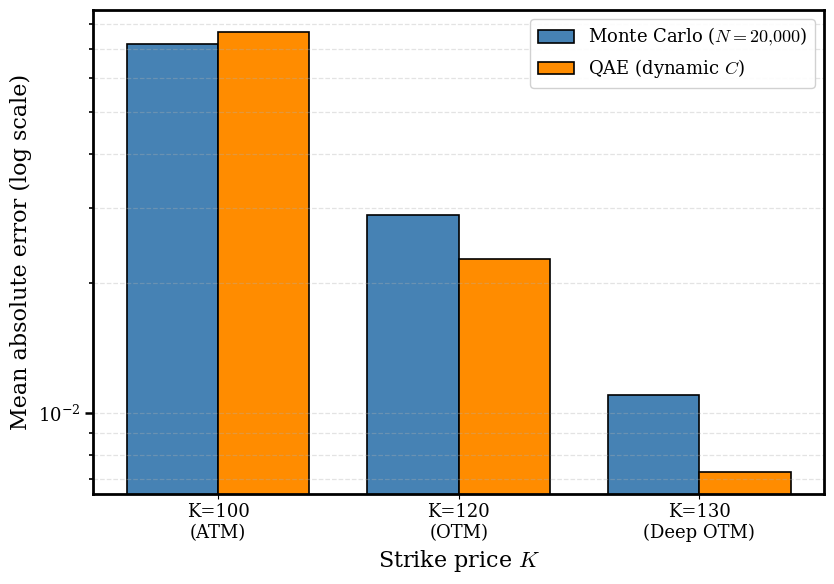

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# --- data from Table 3 (replace with your computed arrays if you have them) ---
strikes    = ["K=100\n(ATM)", "K=120\n(OTM)", "K=130\n(Deep OTM)"]
mc_errors  = [0.0720, 0.0289, 0.0110]
qae_errors = [0.0768, 0.0228, 0.0073]

x = np.arange(len(strikes))
width = 0.38

plt.rcParams.update({"axes.linewidth": 2.0})
fig, ax = plt.subplots(figsize=(8.5, 6))
ax.set_yscale("log")

b1 = ax.bar(x - width/2, mc_errors,  width, color="steelblue",
            edgecolor="black", linewidth=1.2, label="Monte Carlo ($N=20{,}000$)")
b2 = ax.bar(x + width/2, qae_errors, width, color="darkorange",
            edgecolor="black", linewidth=1.2, label="QAE (dynamic $C$)")

ax.set_ylabel("Mean absolute error (log scale)", fontsize=16)
ax.set_xlabel("Strike price $K$", fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(strikes, fontsize=13)
ax.tick_params(axis='y', which='major', labelsize=13, width=1.8, length=6)
ax.tick_params(axis='y', which='minor', width=1.2, length=3)
ax.grid(True, axis='y', which='both', ls="--", alpha=0.35, linewidth=0.9)
ax.legend(fontsize=13, framealpha=0.9)

fig.tight_layout()
fig.savefig("efficiency_comparison.pdf", bbox_inches="tight")   # use in LaTeX
fig.savefig("efficiency_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

In [13]:
# --- numerical values for the quantitative analysis / Table 3 ---
Ks = [100, 120, 130]
labels = ["ATM", "OTM", "Deep OTM"]

print(f"{'K':>6} {'Regime':>10} {'MC err':>9} {'QAE err':>9} {'Speedup':>9}")
speedups = []
for K, lab, mc, qae in zip(Ks, labels, mc_errors, qae_errors):
    s = mc / qae
    speedups.append(s)
    print(f"{K:>6} {lab:>10} {mc:>9.4f} {qae:>9.4f} {s:>8.2f}x")

speedups = np.array(speedups)
print("\n--- summary for the text ---")
print(f"Speedup range: {speedups.min():.2f}x (at K={Ks[int(speedups.argmin())]}) "
      f"to {speedups.max():.2f}x (at K={Ks[int(speedups.argmax())]})")
print(f"QAE error reduction ATM->deep OTM: "
      f"{qae_errors[0]:.4f} -> {qae_errors[-1]:.4f} "
      f"({qae_errors[0]/qae_errors[-1]:.1f}x lower)")
print(f"At K=100 QAE underperforms MC by {(qae_errors[0]/mc_errors[0]-1)*100:.0f}%")

     K     Regime    MC err   QAE err   Speedup
   100        ATM    0.0720    0.0768     0.94x
   120        OTM    0.0289    0.0228     1.27x
   130   Deep OTM    0.0110    0.0073     1.51x

--- summary for the text ---
Speedup range: 0.94x (at K=100) to 1.51x (at K=130)
QAE error reduction ATM->deep OTM: 0.0768 -> 0.0073 (10.5x lower)
At K=100 QAE underperforms MC by 7%
